In [1]:
from datetime import datetime
from getpass import getpass

rdm_url = 'http://localhost:5001/'
idp_name_1 = 'FakeCAS'
idp_username_1 = None
idp_password_1 = None
rdm_project_name_w_metadata = 'TEST-Migration-20250906-METADATA'
rdm_project_name_wo_metadata = 'TEST-Migration-20250906-NO-METADATA'
target_storage_name = 'NII Storage'
target_storage_id = 'osfstorage'
weko_url = 'https://192.168.168.167'
weko_index_name = 'Sample Index'
oauth_client_type = 'direct'
ignore_https_errors = False
default_result_path = None
close_on_fail = False
transition_timeout = 10000


In [2]:
if idp_username_1 is None:
    idp_username_1 = input(prompt=f'Username for {idp_name_1}')
if idp_password_1 is None:
    idp_password_1 = getpass(prompt=f'Password for {idp_username_1}@{idp_name_1}')
(len(idp_username_1), len(idp_password_1))

(29, 13)

In [3]:
import tempfile

work_dir = tempfile.mkdtemp()
if default_result_path is None:
    default_result_path = work_dir
work_dir

'/var/folders/m0/myy2ys0s3cl_73__2gw8fw140000gn/T/tmpniehqtfc'

# MigrationされたプロジェクトのWEKOアドオンによるメタデータ送信の動作確認

- サブシステム名: アドオン
- ページ/アドオン: Metadata, WEKO
- 機能分類: Migration後の動作確認
- シナリオ名: 移行済みメタデータのWEKO送信
- 用意するテストデータ: URL一覧、アカウント(既存ユーザー1: GRDM, WEKO教員以上)


## ウェブブラウザの新規プライベートウィンドウでGRDMトップページを表示する

GRDMトップページが表示されること

In [8]:
import os

# for migrations: make sure scripts/ points to the right place
if not os.path.exists('scripts'):
    os.symlink('../scripts', 'scripts')

import importlib
import pandas as pd

import scripts.playwright
importlib.reload(scripts.playwright)

from scripts.playwright import *
from scripts import grdm

await init_pw_context(close_on_fail=close_on_fail, last_path=default_result_path, ignore_https_errors=ignore_https_errors)


('20250908-072501',
 '/var/folders/m0/myy2ys0s3cl_73__2gw8fw140000gn/T/tmp41qv1t1z')

Start epoch: 1757283903.8104908 seconds


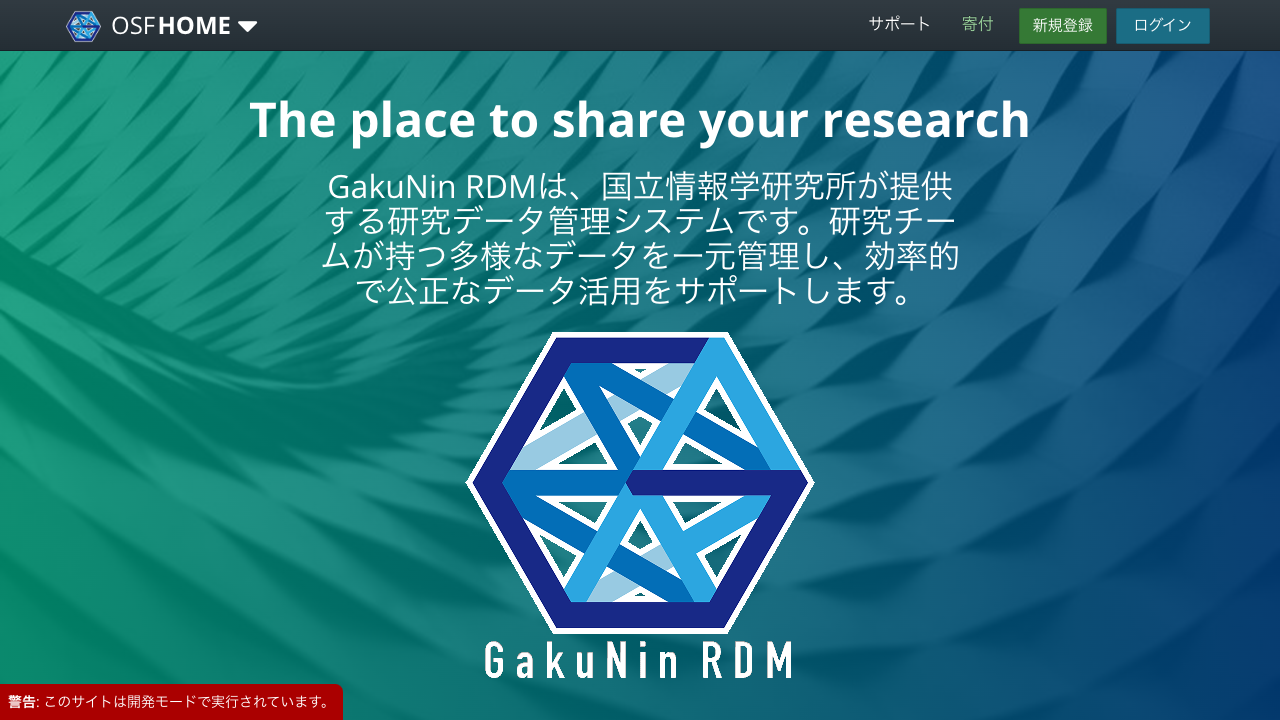

In [9]:
import time

async def _step(page):
    await page.goto(rdm_url)

    # 同意する をクリック
    await page.locator('//button[text() = "同意する"]').click()

    # 同意する が表示されなくなったことを確認
    await expect(page.locator('//button[text() = "同意する"]')).to_have_count(0, timeout=500)

await run_pw(_step)

## ログイン情報を用いてGakuNin RDMにログインする

(IdPに関するログイン情報が与えられた場合、)
GakuNin Embeded DSのプルダウンを展開し、IdPリストから指定されたIdPを選択する。その後、アカウントのID/Passwordを入力して「Login」ボタンを押下する。

(IdPが指定されていない場合、)
CASのログイン操作を実施する。

Start epoch: 1757283906.409528 seconds


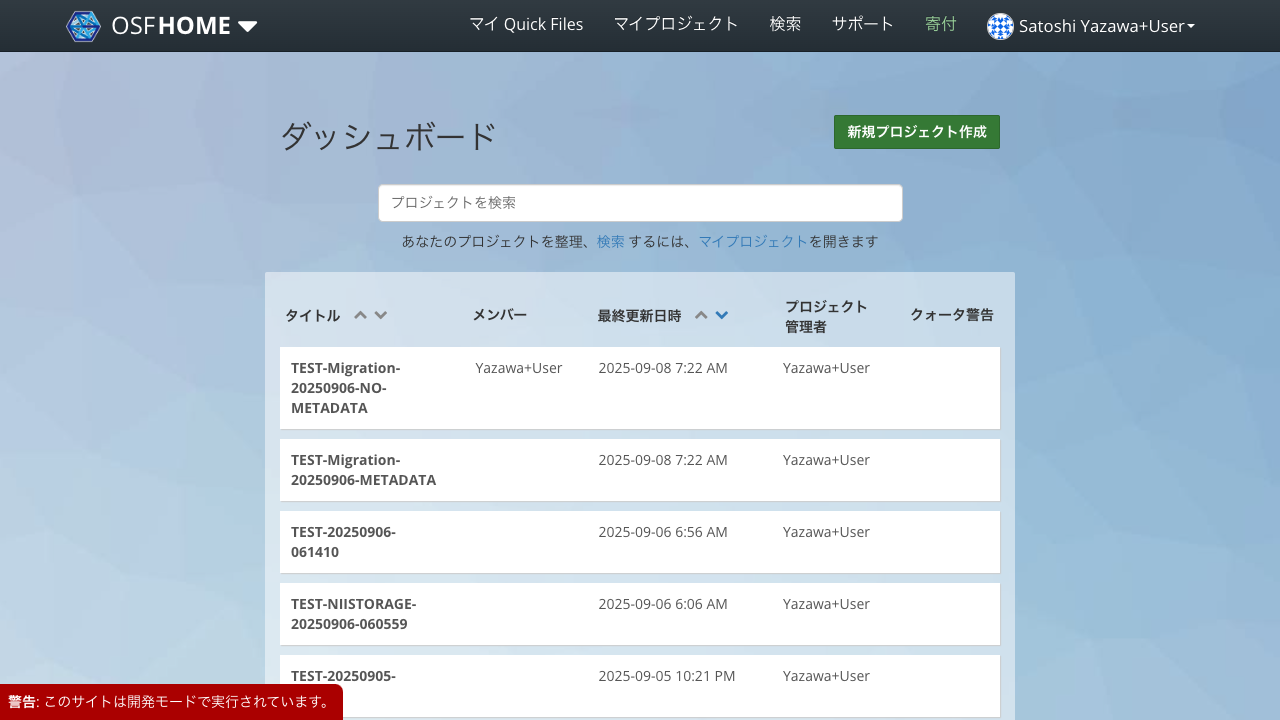

In [10]:
import scripts.grdm
importlib.reload(scripts.grdm)

async def _step(page):
    await scripts.grdm.login(
        page, idp_name_1, idp_username_1, idp_password_1, transition_timeout=transition_timeout
    )

    # プロジェクト一覧が表示されることを確認
    await expect(page.locator(f'//*[text() = "{rdm_project_name_w_metadata}"]')).to_be_visible(timeout=transition_timeout)

await run_pw(_step)

## Metadata紐付け済みのプロジェクトに移動する

プロジェクト一覧から指定されたプロジェクトを選択し、プロジェクト詳細ページに移動する。

Start epoch: 1757283912.785999 seconds


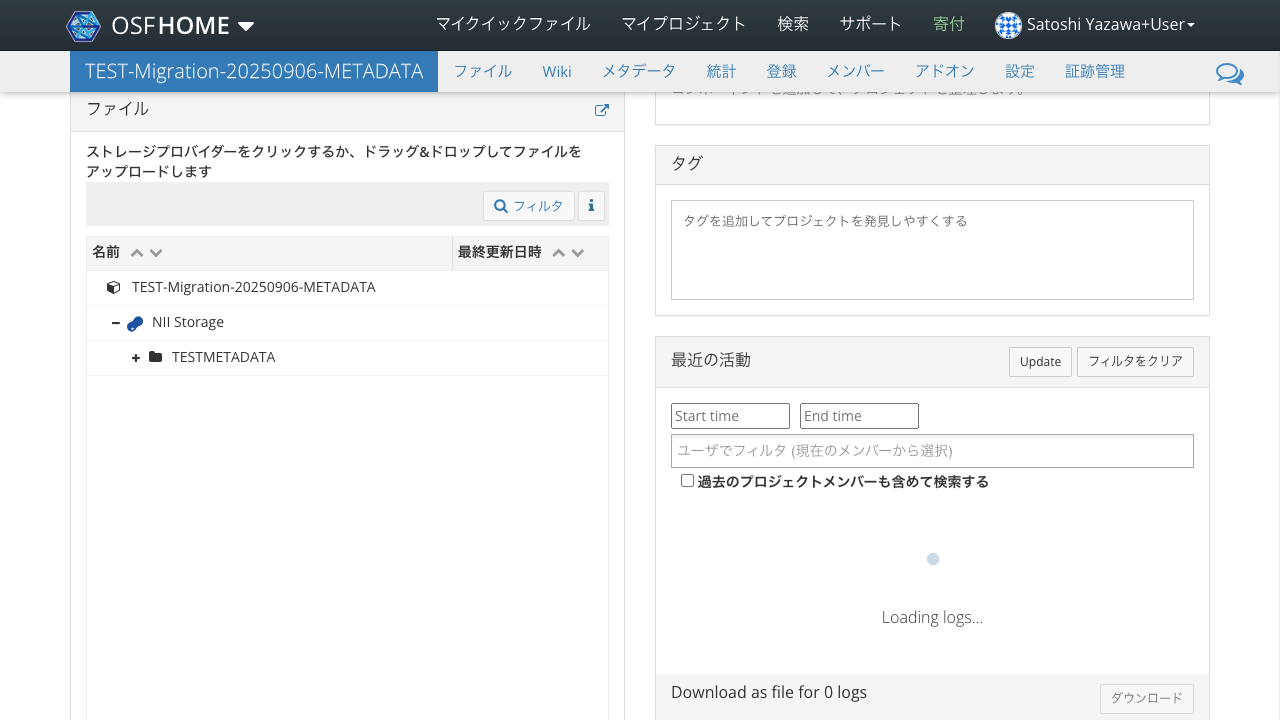

In [11]:
async def _step(page):
    await page.locator(f'//*[@data-test-dashboard-item-title and text()="{rdm_project_name_w_metadata}"]').click()        

    await expect(page.locator('//a[text() = "アドオン"]')).to_be_visible(timeout=transition_timeout)
    await expect(grdm.get_select_expanded_storage_title_locator(page, target_storage_name)).to_be_visible(timeout=transition_timeout)
    time.sleep(1)

    await page.locator('//h3[text()="最近の活動"]').click()
    await expect(page.locator(f'//a[contains(text(), "メタデータ")]')).to_be_visible(timeout=10000)

await run_pw(_step)

## プロジェクトダッシュボードの上部メニューから「メタデータ」をクリックする

メタデータの一覧ページが表示されること

Start epoch: 1757284036.234582 seconds


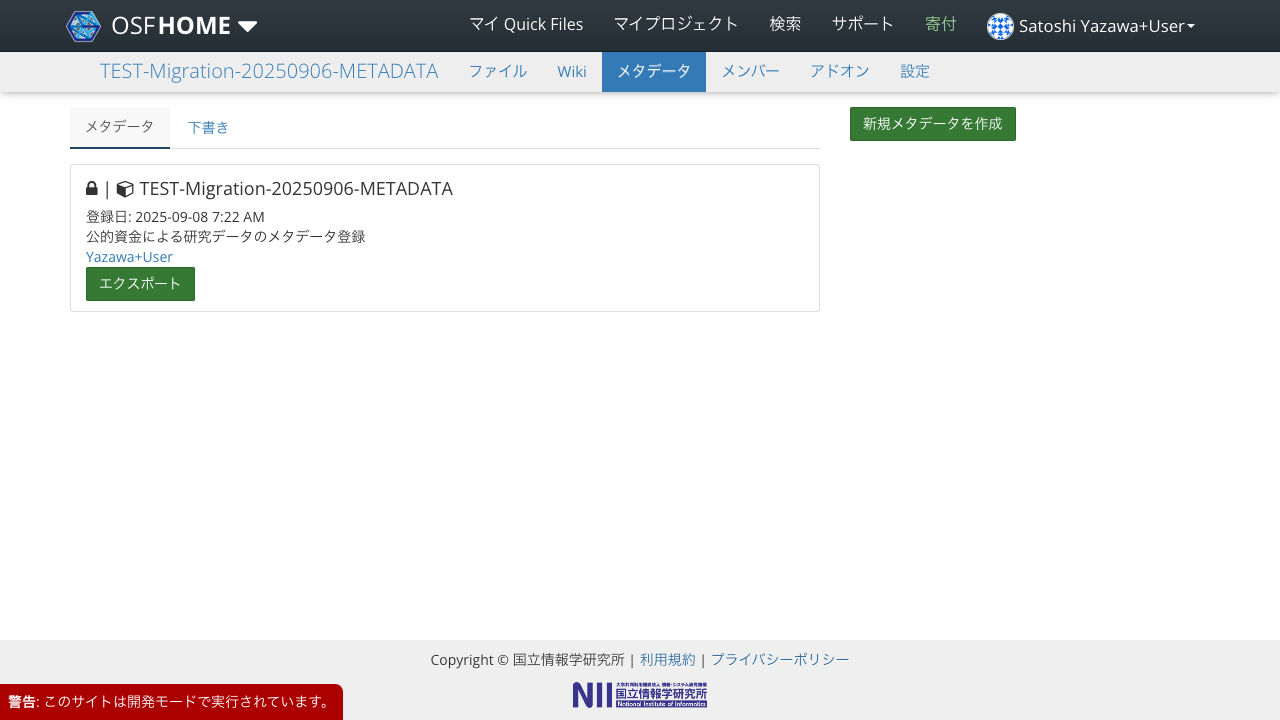

In [ ]:
async def _step(page):
    await page.locator(f'//a[contains(text(), "メタデータ")]').click()
    await expect(page.locator('//*[@data-test-new-metadata-button]')).to_be_visible(timeout=transition_timeout)
    await expect(page.locator('//button[@data-test-registration-card-export]')).to_be_enabled(timeout=transition_timeout)

await run_pw(_step)

## 「エクスポート」をクリックする

言語選択画面が表示されること

Start epoch: 1757284048.7220092 seconds


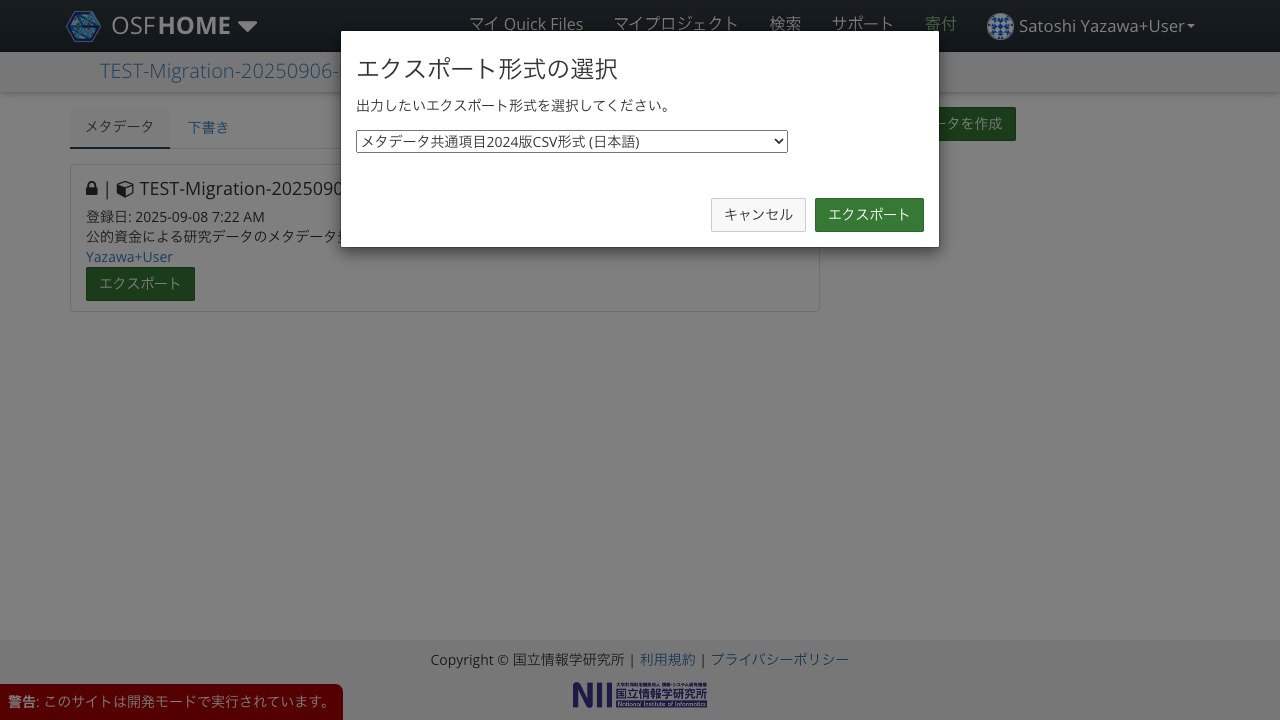

In [14]:
async def _step(page):
    await page.locator('//button[@data-test-registration-card-export]').click()
    
    await expect(page.locator('//select[@id = "registration-report-format-selection"]')).to_be_enabled(timeout=30000)
    time.sleep(1)

await run_pw(_step)

## 「リポジトリ (JAIRO Cloud)に登録」を選択しエクスポート（WEKO送信）する

WEKOへの送信が開始され、登録結果モーダルが表示されること（送信時にKeyError等で失敗しないこと）


In [ ]:
async def _step(page):
    target_option = f'リポジトリ (JAIRO Cloud)に登録 - {weko_index_name}'
    await page.locator('//select[@id = "registration-report-format-selection"]').select_option(label=target_option)
    submit_button = page.locator('//*[@data-test-registration-report-submit]')
    await expect(submit_button).to_be_enabled(timeout=transition_timeout)
    await submit_button.click()
    await expect(submit_button).to_contain_text('エクスポート中', timeout=transition_timeout)
    await expect(page.locator('//*[@data-analytics-scope="RegistrationReport result modal"]')).to_be_visible(timeout=transition_timeout)
    global project_page
    project_page = page

await run_pw(_step)


## WEKOのアイテムリンクをクリックし、アイテムが作成されたことを確認する（Direct）

新しいタブでアイテム詳細が開き、JSON出力リンクと「Public」状態が表示されること


In [ ]:
async def _step(page):
    page = project_page
    popup_future = page.context.wait_for_event('page')
    await page.locator('//a[@data-test-registration-report-result-link]').click()
    popup = await popup_future
    await popup.wait_for_load_state()
    await expect(popup.locator('//a[contains(text(), "JSON")]')).to_be_visible(timeout=transition_timeout)
    await expect(popup.locator('#public_status_form')).to_contain_text('Public', timeout=transition_timeout)

await run_pw(_step)


終了処理を実施。

In [31]:
await finish_pw_context()

Video: /var/folders/m0/myy2ys0s3cl_73__2gw8fw140000gn/T/tmpniehqtfc/video-1.webm
HAR: /var/folders/m0/myy2ys0s3cl_73__2gw8fw140000gn/T/tmpniehqtfc/har.zip


スクリーンキャプチャ動画の取得に失敗しました。
Traceback (most recent call last):
  File "/Users/yazawa/workspace/nii-yamaji/RDM-e2e-test-nb/migrations/scripts/playwright.py", line 168, in _finish_pw_context
    shutil.copyfile(video_path, dest_video_path)
  File "/Users/yazawa/.pyenv/versions/3.11.5/lib/python3.11/shutil.py", line 256, in copyfile
    with open(src, 'rb') as fsrc:
         ^^^^^^^^^^^^^^^
FileNotFoundError: [Errno 2] No such file or directory: '/var/folders/m0/myy2ys0s3cl_73__2gw8fw140000gn/T/tmp41qv1t1z/videos/3111839b5dcefbf1af4f876c59ee3c17.webm'


In [32]:
!rm -fr {work_dir}